# Preparing the data

In [ ]:
from google.colab import files
import os
import zipfile

# Upload the kaggle.json file
uploaded = files.upload()

# Create kaggle directory and move the file
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download the dataset
!kaggle datasets download -d dartweichen/student-life

# Unzip the dataset
with zipfile.ZipFile('student-life.zip', 'r') as zip_ref:
    zip_ref.extractall('student-life-data')

# List the contents
import os
print("Dataset contents:")
for item in os.listdir('student-life-data'):
    print(f" - {item}")

In [ ]:
import os
import pandas as pd
import zipfile

dataset_path = 'student-life-data'
print("Root contents:")
for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        print(f" {item}/")
    else:
        print(f" {item}")

# Let's explore deeper to find EMA files
print("\n Searching for EMA files...")
ema_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if 'EMA' in file.upper() or 'EMA' in root.upper():
            full_path = os.path.join(root, file)
            ema_files.append(full_path)
            #print(f" Found: {full_path}")



print(f"\nTotal EMA-related files found: {len(ema_files)}")

Root contents:
📁 dataset/

🔍 Searching for EMA files...

Total EMA-related files found: 1275


In [ ]:
import json
import pandas as pd
import os

# Configuration
target_survey_types = ['Social', 'Activity', 'Behavior', 'Exercise', 'Study Spaces', 'Stress', 'Mood', 'Mood 2']
date_range_start = '2013-03-27'
date_range_end = '2013-06-01'

def get_all_users_for_survey(survey_type):
    """Get all user IDs that have data for a given survey type"""
    survey_path = f'student-life-data/dataset/EMA/response/{survey_type}'
    if not os.path.exists(survey_path):
        return []

    user_files = [f for f in os.listdir(survey_path) if f.endswith('.json')]
    user_files.sort()  # Sort files alphabetically

    users = [f.replace(f"{survey_type}_", "").replace('.json', '') for f in user_files]
    users.sort()  # Sort users alphabetically

    return users

def process_ema_file(survey_type, user_id):
    """Process EMA file: load JSON, add user_id, drop null columns, convert timestamps to date"""
    file_path = f'student-life-data/dataset/EMA/response/{survey_type}/{survey_type}_{user_id}.json'

    try:
        with open(file_path, 'r') as f:
            data = json.load(f)

        df = pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame([data])
        df.insert(0, 'user_id', user_id)

        # Drop columns named "null"
        null_columns = [col for col in df.columns if str(col).lower() == 'null']
        if null_columns:
            df = df.drop(columns=null_columns)

        # Convert timestamps to date only
        timestamp_columns = [col for col in df.columns if 'time' in col.lower() or 'timestamp' in col.lower()]
        for ts_col in timestamp_columns:
            try:
                df[ts_col] = pd.to_datetime(df[ts_col], unit='s').dt.date
            except Exception:
                pass

        return df

    except Exception:
        return None

def filter_data_by_date_range(dataframes_dict, start_date, end_date):
    """Filter DataFrames to specified date range"""
    start_dt = pd.to_datetime(start_date).date()
    end_dt = pd.to_datetime(end_date).date()

    filtered_dataframes = {}
    for survey_type, df in dataframes_dict.items():
        if 'resp_time' in df.columns:
            mask = (df['resp_time'] >= start_dt) & (df['resp_time'] <= end_dt)
            filtered_dataframes[survey_type] = df[mask]
        else:
            filtered_dataframes[survey_type] = df

    return filtered_dataframes

# Process all survey types for all users
print("Processing EMA files for all users...")
ema_dataframes = {}

for survey_type in target_survey_types:
    print(f"Processing {survey_type}...")

    # Get all users for this survey type
    users = get_all_users_for_survey(survey_type)
    if not users:
        print(f"  No users found for {survey_type}")
        continue

    # Process each user and combine
    all_user_data = []
    for user_id in users:
        df = process_ema_file(survey_type, user_id)
        if df is not None and not df.empty:
            all_user_data.append(df)

    if all_user_data:
        # Combine all user data for this survey type
        combined_df = pd.concat(all_user_data, ignore_index=True)
        ema_dataframes[survey_type] = combined_df
        print(f"  Combined {len(users)} users: {len(combined_df)} total records")
    else:
        print(f"  No data found for {survey_type}")

# Apply date filter
print("\nApplying date filter...")
ema_dataframes = filter_data_by_date_range(ema_dataframes, date_range_start, date_range_end)

print(f"\nFinal dataset summary:")
for survey_type, df in ema_dataframes.items():
    record_count = len(df)
    user_count = df['user_id'].nunique() if 'user_id' in df.columns else 0
    if 'resp_time' in df.columns and record_count > 0:
        date_info = f" ({df['resp_time'].min()} to {df['resp_time'].max()})"
    else:
        date_info = ""
    print(f"{survey_type}: {record_count} records from {user_count} users{date_info}")

# Assign to variables
social_df = ema_dataframes['Social']
activity_df = ema_dataframes['Activity']
behavior_df = ema_dataframes['Behavior']
exercise_df = ema_dataframes['Exercise']
study_spaces_df = ema_dataframes['Study Spaces']
stress_df = ema_dataframes['Stress']
mood_df = ema_dataframes['Mood']
mood2_df = ema_dataframes['Mood 2']

Processing EMA files for all users...
Processing Social...
  Combined 49 users: 1410 total records
Processing Activity...
  Combined 49 users: 833 total records
Processing Behavior...
  Combined 49 users: 814 total records
Processing Exercise...
  Combined 49 users: 763 total records
Processing Study Spaces...
  Combined 49 users: 329 total records
Processing Stress...
  Combined 49 users: 2408 total records
Processing Mood...
  Combined 49 users: 277 total records
Processing Mood 2...
  Combined 49 users: 426 total records

Applying date filter...

Final dataset summary:
Social: 1157 records from 48 users (2013-03-27 to 2013-06-01)
Activity: 822 records from 48 users (2013-03-27 to 2013-06-01)
Behavior: 810 records from 47 users (2013-03-27 to 2013-06-01)
Exercise: 754 records from 46 users (2013-04-01 to 2013-06-01)
Study Spaces: 329 records from 42 users (2013-04-18 to 2013-05-31)
Stress: 2147 records from 48 users (2013-03-27 to 2013-06-01)
Mood: 260 records from 38 users (2013-04-

In [ ]:
activity_df

,user_id,Social2,resp_time,other_relaxing,other_working,relaxing,working,location
0,u00,2,2013-03-28,NaN,NaN,NaN,NaN,NaN
1,u00,1,2013-03-29,NaN,NaN,NaN,NaN,NaN
2,u00,1,2013-03-28,NaN,NaN,NaN,NaN,NaN
3,u00,2,2013-03-29,NaN,NaN,NaN,NaN,NaN
4,u00,3,2013-03-30,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
826,u59,NaN,2013-05-26,4,2,1,1,"43.705819859169424,-72.29087230749428"
827,u59,NaN,2013-05-27,1,4,1,3,"43.70550733990967,-72.2909749019891"
828,u59,NaN,2013-05-29,1,5,2,2,Unknown
829,u59,NaN,2013-05-30,3,3,2,1,"43.705530599690974,-72.29089292697608"


In [ ]:
def clean_dataframe_columns(dataframes_dict):
    """Drop location column and reorder columns with user_id first, resp_time second"""
    cleaned_dataframes = {}

    for survey_type, df in dataframes_dict.items():
        if df is not None:
            # Make a copy to avoid modifying the original
            df_clean = df.copy()

            # Drop location column if it exists
            if 'location' in df_clean.columns:
                df_clean = df_clean.drop(columns=['location'])

            # Reorder columns: user_id first, resp_time second, then the rest
            if 'user_id' in df_clean.columns and 'resp_time' in df_clean.columns:
                other_columns = [col for col in df_clean.columns if col not in ['user_id', 'resp_time']]
                new_column_order = ['user_id', 'resp_time'] + other_columns
                df_clean = df_clean[new_column_order]

            cleaned_dataframes[survey_type] = df_clean
            print(f"{survey_type}: Dropped location={('location' in df.columns)}, Reordered columns")
        else:
            cleaned_dataframes[survey_type] = df

    return cleaned_dataframes

# Re-apply the cleaning properly
print("Cleaning columns...")
ema_dataframes = clean_dataframe_columns(ema_dataframes)


# Update the variable assignments
social_df = ema_dataframes.get('Social')
activity_df = ema_dataframes.get('Activity')
behavior_df = ema_dataframes.get('Behavior')
exercise_df = ema_dataframes.get('Exercise')
study_spaces_df = ema_dataframes.get('Study Spaces')
stress_df = ema_dataframes.get('Stress')
mood_df = ema_dataframes.get('Mood')
mood2_df = ema_dataframes.get('Mood 2')


Cleaning columns...
Social: Dropped location=True, Reordered columns
Activity: Dropped location=True, Reordered columns
Behavior: Dropped location=True, Reordered columns
Exercise: Dropped location=True, Reordered columns
Study Spaces: Dropped location=True, Reordered columns
Stress: Dropped location=True, Reordered columns
Mood: Dropped location=True, Reordered columns
Mood 2: Dropped location=True, Reordered columns

Final verification:
Social: location=False
Activity: location=False
Behavior: location=False
Exercise: location=False
Study Spaces: location=False
Stress: location=False
Mood: location=False
Mood 2: location=False


## Stress Survey

| Column Name | Question | Response Options |
|-------------|----------|------------------|
| **level** | Right now, I am... | 1=A little stressed, 2=Definitely stressed, 3=Stressed out, 4=Feeling good, 5=Feeling great |
| **location** | Location | No predefined options |

## initial user ids

In [ ]:
user_ids = ['u00', 'u01', 'u02', 'u03', 'u04', 'u05', 'u07', 'u08', 'u09',
           'u10', 'u12', 'u13', 'u14', 'u15', 'u16', 'u17', 'u18', 'u19',
           'u20', 'u22', 'u23', 'u24', 'u25', 'u27', 'u30', 'u31', 'u32',
           'u33', 'u34', 'u35', 'u36', 'u39', 'u41', 'u42', 'u43', 'u44',
           'u45', 'u46', 'u47', 'u49', 'u50', 'u51', 'u52', 'u53', 'u54',
           'u56', 'u57', 'u58', 'u59']

all_ids= pd.DataFrame(user_ids, columns=['user_id'])
print(all_ids.head())
print(f"DataFrame shape: {all_ids.shape}")

  user_id
0     u00
1     u01
2     u02
3     u03
4     u04
DataFrame shape: (49, 1)


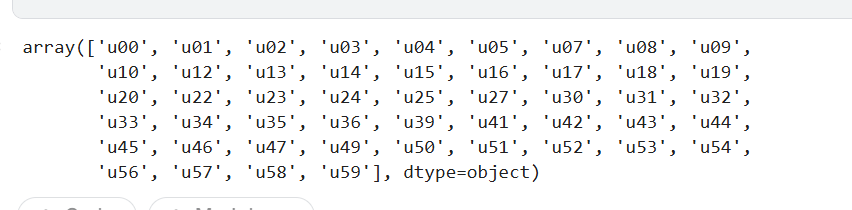

In [ ]:
Mood.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271 entries, 0 to 270
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     271 non-null    object
 1   resp_time   260 non-null    object
 2   happy       259 non-null    object
 3   happyornot  258 non-null    Int64 
 4   sad         259 non-null    object
 5   sadornot    252 non-null    Int64 
dtypes: Int64(2), object(4)
memory usage: 13.4+ KB


In [ ]:
def edit_ids_initial(df):
  return all_ids.merge(df, how='left', on='user_id')
# dict_keys(['Social', 'Activity', 'Behavior', 'Exercise', 'Study Spaces', 'Stress', 'Mood', 'Mood 2'])
Social = edit_ids_initial(Social)
Activity = edit_ids_initial(Activity)
Behavior = edit_ids_initial(Behavior)
Exercise = edit_ids_initial(Exercise)
Study = edit_ids_initial(Study)
Stress = edit_ids_initial(Stress)
Mood = edit_ids_initial(Mood)
Mood2 = edit_ids_initial(Mood2)

In [ ]:
Mood['user_id'].nunique()

49

# Edit ids

In [ ]:
Stress = Stress[Stress['user_id'] != 'u39']
def edit_ids(df):

  unique_ids = sorted(df['user_id'].unique())

  new_ids = [f"u{str(i).zfill(2)}" for i in range(len(unique_ids))]
  id_map = dict(zip(unique_ids, new_ids))

  df['user_id'] = df['user_id'].map(id_map)
  print(df['user_id'].unique())
  print("Total users:", df['user_id'].nunique())
# edit_ids(Mood)
# edit_ids(Mood2)
# edit_ids(Stress)
# edit_ids(Study)
# edit_ids(Exercise)
# edit_ids(Behavior)

In [ ]:
# Stress.user_id.unique()

array(['u00', 'u01', 'u02', 'u03', 'u04', 'u05', 'u06', 'u07', 'u08',
       'u09', 'u10', 'u11', 'u12', 'u13', 'u14', 'u15', 'u16', 'u17',
       'u18', 'u19', 'u20', 'u21', 'u22', 'u23', 'u24', 'u25', 'u26',
       'u27', 'u28', 'u29', 'u30', 'u31', 'u32', 'u33', 'u34', 'u35',
       'u36', 'u37', 'u38', 'u39', 'u40', 'u41', 'u42', 'u43', 'u44',
       'u45', 'u46', 'u47'], dtype=object)

In [ ]:
# Stress = Stress[Stress['user_id'] != 'u39']
# def mapping(df):
#     unique_ids = sorted(df['user_id'].unique())
#     new_ids = [f"u{str(i).zfill(2)}" for i in range(len(unique_ids))]
#     id_map = dict(zip(unique_ids, new_ids))
#     df['user_id'] = df['user_id'].map(id_map)
#     print(df['user_id'].unique())
#     print("Total users:", df['user_id'].nunique())

# mapping(Stress)

['u00' 'u01' 'u02' 'u03' 'u04' 'u05' 'u06' 'u07' 'u08' 'u09' 'u10' 'u11'
 'u12' 'u13' 'u14' 'u15' 'u16' 'u17' 'u18' 'u19' 'u20' 'u21' 'u22' 'u23'
 'u24' 'u25' 'u26' 'u27' 'u28' 'u29' 'u30' 'u31' 'u32' 'u33' 'u34' 'u35'
 'u36' 'u37' 'u38' 'u39' 'u40' 'u41' 'u42' 'u43' 'u44' 'u45' 'u46' 'u47']
Total users: 48


In [ ]:
Stress.tail(10)

,user_id,resp_time,stress_level,stress_category
2138,u47,2013-05-26,4.0,Good
2139,u47,2013-05-27,4.0,Good
2140,u47,2013-05-29,2.0,Stressed
2141,u47,2013-05-28,2.0,Stressed
2142,u47,2013-05-28,2.0,Stressed
2143,u47,2013-05-29,2.0,Stressed
2144,u47,2013-05-30,2.0,Stressed
2145,u47,2013-05-29,2.0,Stressed
2146,u47,2013-06-01,1.0,Neutral
2147,u47,2013-06-01,5.0,Good


# Master Table

In [ ]:
start_date = '2013-03-27'
end_date   = '2013-06-01'
dates = pd.date_range(start=start_date, end=end_date)
dates_df = pd.DataFrame({'resp_time': dates})

ids = [f"u{str(i).zfill(2)}" for i in range(48)]
ids_df   = pd.DataFrame({'user_id': ids})

all_users_dates = ids_df.merge(dates_df, how='cross')
all_users_dates.shape   #  (3216, 2)

(3216, 2)

# Stress output

In [ ]:
Stress = ema_dataframes['Stress']

In [ ]:
Stress.head()

,user_id,resp_time,level
8,u00,2013-03-27,1
9,u00,2013-03-28,4
10,u00,2013-03-28,1
11,u00,2013-03-28,2
12,u00,2013-03-28,2


In [ ]:
Stress.loc[Stress.user_id=='u39']

,user_id,resp_time,level
1427,u39,2013-04-02,1
1428,u39,2013-04-10,1
1429,u39,2013-04-16,1
1430,u39,2013-04-10,1
1431,u39,2013-04-10,1
1432,u39,2013-04-10,1
1433,u39,2013-04-13,1
1434,u39,2013-04-16,1
1435,u39,2013-04-17,1
1436,u39,2013-04-25,1


In [ ]:
Stress.rename(columns = {'level':'stress_level'},inplace=True)

In [ ]:
Stress['resp_time']= pd.to_datetime(Stress['resp_time'])
Stress['stress_level'] = Stress['stress_level'].astype('Int64')

In [ ]:
Stress.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2147 entries, 8 to 2393
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       2147 non-null   object        
 1   resp_time     2147 non-null   datetime64[ns]
 2   stress_level  2143 non-null   Int64         
dtypes: Int64(1), datetime64[ns](1), object(1)
memory usage: 133.7+ KB


In [ ]:
Stress.stress_level.describe()

,stress_level
count,2143.0
mean,2.253383
std,1.359583
min,1.0
25%,1.0
50%,2.0
75%,4.0
max,5.0


In [ ]:
Stress.loc[Stress.user_id=='u07'].sort_values('resp_time')

,user_id,resp_time,stress_level
254,u07,2013-03-27,2
256,u07,2013-03-27,4
257,u07,2013-03-27,4
258,u07,2013-03-27,1
259,u07,2013-03-27,1
260,u07,2013-03-27,1
263,u07,2013-03-28,4
270,u07,2013-03-28,1
268,u07,2013-03-28,1
266,u07,2013-03-28,4


In [ ]:
Stress.user_id.unique(), Stress.user_id.nunique()

(array(['u00', 'u01', 'u02', 'u03', 'u04', 'u05', 'u07', 'u08', 'u09',
        'u10', 'u12', 'u14', 'u15', 'u16', 'u17', 'u18', 'u19', 'u20',
        'u22', 'u23', 'u24', 'u25', 'u27', 'u30', 'u31', 'u32', 'u33',
        'u34', 'u35', 'u36', 'u39', 'u41', 'u42', 'u43', 'u44', 'u45',
        'u46', 'u47', 'u49', 'u50', 'u51', 'u52', 'u53', 'u54', 'u56',
        'u57', 'u58', 'u59'], dtype=object),
 48)

In [ ]:
start_date = '2013-03-27'
end_date   = '2013-06-01'
dates = pd.date_range(start=start_date, end=end_date)
dates_df = pd.DataFrame({'resp_time': dates})

ids = ['u13']
ids_df   = pd.DataFrame({'user_id': ids})

user_13 = ids_df.merge(dates_df, how='cross')
user_13.head()

,user_id,resp_time
0,u13,2013-03-27
1,u13,2013-03-28
2,u13,2013-03-29
3,u13,2013-03-30
4,u13,2013-03-31


In [ ]:
Stress_13 = pd.concat([Stress,user_13],ignore_index=True)
Stress_13.shape

(2214, 3)

In [ ]:
Stress_13.loc[Stress_13.user_id=='u13']

,user_id,resp_time,stress_level
2147,u13,2013-03-27,<NA>
2148,u13,2013-03-28,<NA>
2149,u13,2013-03-29,<NA>
2150,u13,2013-03-30,<NA>
2151,u13,2013-03-31,<NA>
...,...,...,...
2209,u13,2013-05-28,<NA>
2210,u13,2013-05-29,<NA>
2211,u13,2013-05-30,<NA>
2212,u13,2013-05-31,<NA>


In [ ]:
# edit ids
Stress_13 = Stress_13.loc[Stress_13['user_id'] != 'u39']
def mapping(df):
    unique_ids = sorted(df['user_id'].unique())
    new_ids = [f"u{str(i).zfill(2)}" for i in range(len(unique_ids))]
    id_map = dict(zip(unique_ids, new_ids))
    df['user_id'] = df['user_id'].map(id_map)
    print(df['user_id'].unique())
    print("Total users:", df['user_id'].nunique())


mapping(Stress_13)

['u00' 'u01' 'u02' 'u03' 'u04' 'u05' 'u06' 'u07' 'u08' 'u09' 'u10' 'u12'
 'u13' 'u14' 'u15' 'u16' 'u17' 'u18' 'u19' 'u20' 'u21' 'u22' 'u23' 'u24'
 'u25' 'u26' 'u27' 'u28' 'u29' 'u30' 'u31' 'u32' 'u33' 'u34' 'u35' 'u36'
 'u37' 'u38' 'u39' 'u40' 'u41' 'u42' 'u43' 'u44' 'u45' 'u46' 'u47' 'u11']
Total users: 48


In [ ]:
Stress_dedup = Stress_13.drop_duplicates(subset=['user_id', 'resp_time'], keep='first')# drop duplicates

In [ ]:
Stress_dedup.reset_index(drop=True,inplace=True)

In [ ]:
# Merge with master table
start_date = '2013-03-27'
end_date   = '2013-06-01'
dates = pd.date_range(start=start_date, end=end_date)
dates_df = pd.DataFrame({'resp_time': dates})

ids = [f"u{str(i).zfill(2)}" for i in range(48)]
ids_df   = pd.DataFrame({'user_id': ids})

all_users_dates = ids_df.merge(dates_df, how='cross')
all_users_dates.shape   #  (3216, 2)
stress = all_users_dates.merge(Stress_dedup,how='left', on =['user_id', 'resp_time'])
stress

,user_id,resp_time,stress_level
0,u00,2013-03-27,1
1,u00,2013-03-28,4
2,u00,2013-03-29,4
3,u00,2013-03-30,4
4,u00,2013-03-31,4
...,...,...,...
3211,u47,2013-05-28,2
3212,u47,2013-05-29,2
3213,u47,2013-05-30,5
3214,u47,2013-05-31,5


In [ ]:
stress.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3216 entries, 0 to 3215
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       3216 non-null   object        
 1   resp_time     3216 non-null   datetime64[ns]
 2   stress_level  1223 non-null   Int64         
dtypes: Int64(1), datetime64[ns](1), object(1)
memory usage: 78.6+ KB


In [ ]:
stress['resp_time'].min() , stress['resp_time'].max()

(Timestamp('2013-03-27 00:00:00'), Timestamp('2013-06-01 00:00:00'))

In [ ]:
stress.loc[stress.user_id=='u11'].head(25)

,user_id,resp_time,stress_level
737,u11,2013-03-27,<NA>
738,u11,2013-03-28,<NA>
739,u11,2013-03-29,<NA>
740,u11,2013-03-30,<NA>
741,u11,2013-03-31,<NA>
742,u11,2013-04-01,<NA>
743,u11,2013-04-02,<NA>
744,u11,2013-04-03,<NA>
745,u11,2013-04-04,<NA>
746,u11,2013-04-05,<NA>


In [ ]:
stress.stress_level.value_counts()

,count
stress_level,
1,531
4,222
2,221
3,175
5,74


In [ ]:
stress['stress_level_2'] = stress['stress_level'].astype(str)

In [ ]:
stress['stress_level_2'] = stress['stress_level_2'].replace({'5':"feeling_great",'4':"feeling_good",'3':"stressed_out",'2':"stressed",'1':"little_stress"})

In [ ]:
stress['stress_level_2'] = stress['stress_level_2'].replace({"feeling_great":1,"feeling_good":2,"stressed_out":5,"stressed":4,"little_stress":3})

In [ ]:
stress.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3216 entries, 0 to 3215
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         3216 non-null   object        
 1   resp_time       3216 non-null   datetime64[ns]
 2   stress_level    1223 non-null   Int64         
 3   stress_level_2  3216 non-null   object        
dtypes: Int64(1), datetime64[ns](1), object(2)
memory usage: 103.8+ KB


In [ ]:
stress['stress_level_2'] = pd.to_numeric(stress['stress_level_2'], errors='coerce')

In [ ]:
stress['stress_level_2'].value_counts()

,count
stress_level_2,
3.0,531
2.0,222
4.0,221
5.0,175
1.0,74


In [ ]:
stress['stress_level_2'] = stress.groupby('user_id')['stress_level_2'].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

In [ ]:
stress.stress_level_2.value_counts()

,count
stress_level_2,
3.000000,1285
4.000000,464
2.000000,428
5.000000,354
1.000000,118
...,...
3.416667,1
3.583333,1
3.833333,1


In [ ]:
stress.loc[stress.stress_level_2.isna()]

,user_id,resp_time,stress_level,stress_level_2
737,u11,2013-03-27,<NA>,NaN
738,u11,2013-03-28,<NA>,NaN
739,u11,2013-03-29,<NA>,NaN
740,u11,2013-03-30,<NA>,NaN
741,u11,2013-03-31,<NA>,NaN
...,...,...,...,...
799,u11,2013-05-28,<NA>,NaN
800,u11,2013-05-29,<NA>,NaN
801,u11,2013-05-30,<NA>,NaN
802,u11,2013-05-31,<NA>,NaN


In [ ]:
stress.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3216 entries, 0 to 3215
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         3216 non-null   object        
 1   resp_time       3216 non-null   datetime64[ns]
 2   stress_level    1223 non-null   Int64         
 3   stress_level_2  3149 non-null   float64       
dtypes: Int64(1), datetime64[ns](1), float64(1), object(1)
memory usage: 103.8+ KB


In [ ]:
import numpy as np
stress['stress_category'] = np.where(
    stress['stress_level_2'].notna() & (stress['stress_level_2'] <= 3),
    'Good',
    'Stressed'
)

stress.head()

,user_id,resp_time,stress_level,stress_level_2,stress_category
0,u00,2013-03-27,1,3.0,Good
1,u00,2013-03-28,4,2.0,Good
2,u00,2013-03-29,4,2.0,Good
3,u00,2013-03-30,4,2.0,Good
4,u00,2013-03-31,4,2.0,Good


In [ ]:
stress.isna().sum()

,0
user_id,0
resp_time,0
stress_level,1993
stress_level_2,67
stress_category,0


In [ ]:
stress.stress_category.value_counts()

,count
stress_category,
Good,2041
Stressed,1175


In [ ]:
stress = stress.rename(columns={'resp_time':'date'})

In [ ]:
stress.loc[stress.stress_level_2.isna()]

,user_id,date,stress_level,stress_level_2,stress_category
737,u11,2013-03-27,<NA>,NaN,Stressed
738,u11,2013-03-28,<NA>,NaN,Stressed
739,u11,2013-03-29,<NA>,NaN,Stressed
740,u11,2013-03-30,<NA>,NaN,Stressed
741,u11,2013-03-31,<NA>,NaN,Stressed
...,...,...,...,...,...
799,u11,2013-05-28,<NA>,NaN,Stressed
800,u11,2013-05-29,<NA>,NaN,Stressed
801,u11,2013-05-30,<NA>,NaN,Stressed
802,u11,2013-05-31,<NA>,NaN,Stressed


In [ ]:
stress.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3216 entries, 0 to 3215
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   user_id          3216 non-null   object        
 1   date             3216 non-null   datetime64[ns]
 2   stress_level     1223 non-null   Int64         
 3   stress_level_2   3149 non-null   float64       
 4   stress_category  3216 non-null   object        
dtypes: Int64(1), datetime64[ns](1), float64(1), object(2)
memory usage: 128.9+ KB


In [ ]:
stress.to_csv('stress_output4.csv')

In [ ]:
Stress.user_id.nunique()

48

In [ ]:
stress.drop(columns=['stress_level'],inplace=True)

In [ ]:
stress.rename(columns={'stress_level_2':'stress_level'},inplace=True)

In [ ]:
stress.iloc[5:10]

,user_id,date,stress_level,stress_category
5,u00,2013-04-01,2.5,Good
6,u00,2013-04-02,3.0,Good
7,u00,2013-04-03,4.0,Stressed
8,u00,2013-04-04,2.0,Good
9,u00,2013-04-05,4.0,Stressed
